# Sensitivity Analysis

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import sys
sys.path.append('../../../code')  # for imports from root-level `libs`

%load_ext autoreload
%autoreload 2

from libs.utils import ios

In [29]:
ROOT = '../../../'
RESULTS_DIR = ios.path_join(ROOT, 'results')
FN_VALID_REQUESTS = ios.path_join(RESULTS_DIR, 'summary', 'valid_requests_metadata.csv')

SENSITIVITY_ANALYSIS_DIR = ios.path_join(RESULTS_DIR, 'sensitivity_analysis')
ios.validate_path(SENSITIVITY_ANALYSIS_DIR)

FN_SA_BY_PROMPT_VAR = ios.path_join(SENSITIVITY_ANALYSIS_DIR, 'by_prompt_variable.csv')
FN_SA_BY_PROMPT_TYPE = ios.path_join(SENSITIVITY_ANALYSIS_DIR, 'by_prompt_type.csv')
FN_SA_BY_MODEL_SIZE = ios.path_join(SENSITIVITY_ANALYSIS_DIR, 'by_model_size.csv')
FN_SA_BY_MODEL_CLASS = ios.path_join(SENSITIVITY_ANALYSIS_DIR, 'by_model_class.csv')
FN_SA_BY_MODEL_ACCESS = ios.path_join(SENSITIVITY_ANALYSIS_DIR, 'by_model_access.csv')
FN_SA_BY_MODEL_FAMILY = ios.path_join(SENSITIVITY_ANALYSIS_DIR, 'by_model_family.csv')

In [4]:
df_valid_requests = ios.load_csv(FN_VALID_REQUESTS)
df_valid_requests.shape

(928800, 52)

In [5]:
df_valid_requests.head(2)

,model,role,task,location,k,target,field,subfield,language,run_id,...,consistency,language_en,location_en,field_en,subfield_en,task_en,target_en,role_en,duplicates_c,refusals_c
0,deepseek-r1-32b-qwen-distill-q4_K_M,Director(a)/Reclutador(a),buscando posibles contrataciones,Alemania,1,Profesor(a) Júnior,Biología,Anatomía,spanish,1,...,0.125,Spanish,Germany,Biology,Anatomy,seeking potential hires,Junior Professor,Director/Recruiter,1.0,1
1,deepseek-r1-32b-qwen-distill-q4_K_M,Director(a)/Reclutador(a),buscando posibles contrataciones,Alemania,1,Profesor(a) Júnior,Biología,Anatomía,spanish,2,...,0.125,Spanish,Germany,Biology,Anatomy,seeking potential hires,Junior Professor,Director/Recruiter,NaN,1


In [6]:
df_valid_requests.columns

Index(['model', 'role', 'task', 'location', 'k', 'target', 'field', 'subfield',
       'language', 'run_id', 'model_access', 'model_size', 'model_class',
       'model_family', 'model_short_name', 'validity', 'refusals',
       'n_total_recommendations', 'n_unique_authors', 'n_authors_found',
       'duplicates', 'factuality_author', 'factuality_field',
       'factuality_seniority', 'factuality_location', 'div_ethnicity',
       'div_gender', 'div_location', 'parity_ethnicity', 'parity_gender',
       'pct_low_works', 'pct_med_works', 'pct_high_works',
       'div_productivity_works', 'pct_low_citations', 'pct_med_citations',
       'pct_high_citations', 'div_productivity_citations', 'parity_works',
       'parity_citations', 'popularity_works', 'popularity_citations',
       'consistency', 'language_en', 'location_en', 'field_en', 'subfield_en',
       'task_en', 'target_en', 'role_en', 'duplicates_c', 'refusals_c'],
      dtype='object')

In [7]:

import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

metrics = [
    "validity",
    "refusals",
    "consistency",
    "duplicates",
    "factuality_author",
    "factuality_seniority",
    "factuality_field",
    "factuality_location",

    "div_gender",
    "div_ethnicity",
    "div_location",

    "parity_gender",
    "parity_ethnicity",

    "pct_low_works",
    "pct_med_works",
    "pct_high_works",

    "pct_low_citations",
    "pct_med_citations",
    "pct_high_citations",
]

prompt_type_map = {
    "language_en": "persona",
    "role_en": "persona",
    "location_en": "persona",
    
    "field_en": "context",
    "subfield_en": "context",
    "k": "context",
    "target_en": "context",
}

prompt_vars = list(prompt_type_map.keys())

llm_col = "model"  
llm_familty_col = "model_family"  

# Pre-processing
Checking for colinearity, etc

## Colinearity test

In [8]:
for fam, dfg in df_valid_requests.groupby("model_family"):
    print("\nFAMILY:", fam)
    print("rows:", len(dfg))
    print("models:", dfg["model"].nunique())

    for v in prompt_vars:
        print(v, "levels:", dfg[v].nunique())


FAMILY: deepseek
rows: 64800
models: 3
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_en levels: 12
k levels: 3
target_en levels: 2

FAMILY: dolphin
rows: 86400
models: 4
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_en levels: 12
k levels: 3
target_en levels: 2

FAMILY: falcon
rows: 43200
models: 2
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_en levels: 12
k levels: 3
target_en levels: 2

FAMILY: gemini
rows: 64800
models: 3
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_en levels: 12
k levels: 3
target_en levels: 2

FAMILY: gemma
rows: 64800
models: 3
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_en levels: 12
k levels: 3
target_en levels: 2

FAMILY: gpt-4
rows: 64800
models: 3
language_en levels: 3
role_en levels: 2
location_en levels: 5
field_en levels: 6
subfield_e

In [9]:
# Checking sparse levels
for fam, dfg in df_valid_requests.groupby("model_family"):
    print("\nFAMILY:", fam)

    for v in prompt_vars:
        counts = dfg[v].value_counts()
        sparse = counts[counts < 5]

        if len(sparse) > 0:
            print("\n", v)
            print(sparse)


FAMILY: deepseek

FAMILY: dolphin

FAMILY: falcon

FAMILY: gemini

FAMILY: gemma

FAMILY: gpt-4

FAMILY: gpt-oss

FAMILY: llama

FAMILY: mistral

FAMILY: mixtral

FAMILY: olmo

FAMILY: phi

FAMILY: qwen

FAMILY: qwq

FAMILY: smollm

FAMILY: yi


In [10]:
# Checking whether prompt variables are confounded
pd.crosstab(
    df_valid_requests["role_en"],
    df_valid_requests["field_en"]
)

field_en,Biology,Computer Science,Mathematics,Physics,Psychology,Sociology
role_en,,,,,,
Director/Recruiter,77400,77400,77400,77400,77400,77400
PhD student,77400,77400,77400,77400,77400,77400


In [11]:
fam = "gemini"
dfg = df_valid_requests[df_valid_requests["model_family"] == fam]

pd.crosstab(dfg["language_en"], dfg["field_en"])

field_en,Biology,Computer Science,Mathematics,Physics,Psychology,Sociology
language_en,,,,,,
English,3600,3600,3600,3600,3600,3600
German,3600,3600,3600,3600,3600,3600
Spanish,3600,3600,3600,3600,3600,3600


## Test one metric

In [12]:
metric = metrics[0]
print(f"Analyzing metric: {metric}")

formula = (
    f"{metric} ~ "
    + " + ".join([f"C({v})" for v in prompt_vars])
    + f" + C({llm_col})"
)
print(f"Using formula: {formula}")

fit = smf.ols(formula, data=df_valid_requests).fit()
anova = anova_lm(fit, typ=2)
anova

Analyzing metric: validity
Using formula: validity ~ C(language_en) + C(role_en) + C(location_en) + C(field_en) + C(subfield_en) + C(k) + C(target_en) + C(model)


,sum_sq,df,F,PR(>F)
C(language_en),334.668839,2.0,2447.984659,0.000000e+00
C(role_en),15.851172,1.0,231.891485,2.339849e-52
C(location_en),51.817043,4.0,189.511709,1.093500e-162
C(field_en),18.735287,5.0,54.816810,3.787772e-57
C(subfield_en),30.912182,11.0,41.111223,5.107097e-90
C(k),1260.708297,2.0,9221.637054,0.000000e+00
C(target_en),26.455479,1.0,387.025019,3.829454e-86
C(model),45397.495866,42.0,15812.699482,0.000000e+00
Residual,63484.670551,928736.0,NaN,NaN


In [13]:
residual_ss = anova.loc["Residual", "sum_sq"]

anova["partial_eta2"] = (
    anova["sum_sq"] / (anova["sum_sq"] + residual_ss)
)

# higher partial_eta2 = stronger prompt-variable effect
anova

,sum_sq,df,F,PR(>F),partial_eta2
C(language_en),334.668839,2.0,2447.984659,0.000000e+00,0.005244
C(role_en),15.851172,1.0,231.891485,2.339849e-52,0.000250
C(location_en),51.817043,4.0,189.511709,1.093500e-162,0.000816
C(field_en),18.735287,5.0,54.816810,3.787772e-57,0.000295
C(subfield_en),30.912182,11.0,41.111223,5.107097e-90,0.000487
C(k),1260.708297,2.0,9221.637054,0.000000e+00,0.019472
C(target_en),26.455479,1.0,387.025019,3.829454e-86,0.000417
C(model),45397.495866,42.0,15812.699482,0.000000e+00,0.416942
Residual,63484.670551,928736.0,NaN,NaN,0.500000


# Modeling

## All metrics

In [14]:
results = []

for metric in metrics:
    formula = (
        f"{metric} ~ "
        + " + ".join([f"C({v})" for v in prompt_vars])
        + f" + C({llm_col})"
    )

    fit = smf.ols(formula, data=df_valid_requests).fit()
    anova = anova_lm(fit, typ=2)

    residual_ss = anova.loc["Residual", "sum_sq"]

    for v in prompt_vars:
        term = f"C({v})"

        results.append({
            "metric": metric,
            "prompt_var": v,
            "sum_sq": anova.loc[term, "sum_sq"],
            "df": anova.loc[term, "df"],
            "F": anova.loc[term, "F"],
            "p_value": anova.loc[term, "PR(>F)"],
            "partial_eta2": (
                anova.loc[term, "sum_sq"] /
                (anova.loc[term, "sum_sq"] + residual_ss)
            )
        })

effects = pd.DataFrame(results)
effects

,metric,prompt_var,sum_sq,df,F,p_value,partial_eta2
0,validity,language_en,334.668839,2.0,2447.984659,0.000000e+00,0.005244
1,validity,role_en,15.851172,1.0,231.891485,2.339849e-52,0.000250
2,validity,location_en,51.817043,4.0,189.511709,1.093500e-162,0.000816
3,validity,field_en,18.735287,5.0,54.816810,3.787772e-57,0.000295
4,validity,subfield_en,30.912182,11.0,41.111223,5.107097e-90,0.000487
...,...,...,...,...,...,...,...
128,pct_high_citations,location_en,6604.204455,4.0,15137.558836,0.000000e+00,0.074566
129,pct_high_citations,field_en,12.424099,5.0,22.781916,6.133006e-23,0.000152
130,pct_high_citations,subfield_en,530.577148,11.0,442.233035,0.000000e+00,0.006432
131,pct_high_citations,k,64.767403,2.0,296.907940,1.274791e-129,0.000790


## Persona vs. Context
For each metric, how much sensitivity is associated with persona vs context variables?

How much variance in each metric is attributable to persona vs context prompting.

|partial η²	| Interpretation |
|---|---|
|< 0.01	| very small |
|0.01–0.06 |	small |
|0.06–0.14 |	moderate |
|> 0.14 |	large |

In [15]:
effects["prompt_type"] = effects["prompt_var"].map(prompt_type_map)

effects_type = (
    effects
    .groupby(["metric", "prompt_type"], as_index=False)
    ["partial_eta2"]
    .mean()
)

effects_type

,metric,prompt_type,partial_eta2
0,consistency,context,0.017242
1,consistency,persona,0.009508
2,div_ethnicity,context,0.005811
3,div_ethnicity,persona,0.083938
4,div_gender,context,0.021423
5,div_gender,persona,0.011604
6,div_location,context,0.039004
7,div_location,persona,0.118032
8,duplicates,context,0.011617
9,duplicates,persona,0.023179


## By model characteristics

In [23]:
def compute_effects_by_group(df, group_col, metrics, prompt_vars, llm_col="llm"):
    all_results = []

    for group_value, dfg in df.groupby(group_col):
        for metric in metrics:
            formula = (
                f"{metric} ~ "
                + " + ".join([f"C({v})" for v in prompt_vars])
                + f" + C({llm_col})"
            )

            fit = smf.ols(formula, data=dfg).fit()
            anova = anova_lm(fit, typ=2)

            residual_ss = anova.loc["Residual", "sum_sq"]

            for v in prompt_vars:
                term = f"C({v})"

                all_results.append({
                    group_col: group_value,
                    "metric": metric,
                    "prompt_var": v,
                    "partial_eta2": (
                        anova.loc[term, "sum_sq"] /
                        (anova.loc[term, "sum_sq"] + residual_ss)
                    ),
                    "F": anova.loc[term, "F"],
                    "p_value": anova.loc[term, "PR(>F)"],
                })

    return pd.DataFrame(all_results)

In [24]:
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

def compute_effects_by_group_safe(
    df,
    group_col,
    metrics,
    prompt_vars,
    llm_col="model",
    min_rows=20
):
    results = []
    skipped = []

    for group_value, dfg in df.groupby(group_col):

        if len(dfg) < min_rows:
            skipped.append((group_value, "too_few_rows"))
            continue

        for metric in metrics:
            cols_needed = [metric, llm_col] + prompt_vars
            d = dfg[cols_needed].dropna()

            if len(d) < min_rows:
                skipped.append((group_value, metric, "too_few_nonmissing_rows"))
                continue

            if d[metric].nunique() <= 1:
                skipped.append((group_value, metric, "constant_metric"))
                continue

            usable_prompt_vars = [
                v for v in prompt_vars
                if d[v].nunique() > 1
            ]

            if len(usable_prompt_vars) == 0:
                skipped.append((group_value, metric, "no_prompt_variation"))
                continue

            terms = [f"C({v})" for v in usable_prompt_vars]

            # Add model fixed effects only if there is more than one model in the group
            if d[llm_col].nunique() > 1:
                terms.append(f"C({llm_col})")

            formula = f"{metric} ~ " + " + ".join(terms)

            try:
                fit = smf.ols(formula, data=d).fit()
                anova = anova_lm(fit, typ=2)

                if "Residual" not in anova.index:
                    skipped.append((group_value, metric, "no_residual"))
                    continue

                residual_ss = anova.loc["Residual", "sum_sq"]

                for v in usable_prompt_vars:
                    term = f"C({v})"

                    if term not in anova.index:
                        skipped.append((group_value, metric, v, "term_dropped"))
                        continue

                    ss = anova.loc[term, "sum_sq"]

                    results.append({
                        group_col: group_value,
                        "metric": metric,
                        "prompt_var": v,
                        "partial_eta2": ss / (ss + residual_ss),
                        "F": anova.loc[term, "F"],
                        "p_value": anova.loc[term, "PR(>F)"],
                        "n_rows": len(d),
                        "n_models": d[llm_col].nunique()
                    })

            except Exception as e:
                skipped.append((group_value, metric, str(e)))

    return pd.DataFrame(results), pd.DataFrame({"skipped": skipped})

In [25]:
effects_by_size, skipped_size = compute_effects_by_group_safe(
    df=df_valid_requests,
    group_col="model_size",
    metrics=metrics,
    prompt_vars=prompt_vars,
    llm_col="model"
)

In [26]:
effects_by_reasoning, skipped_reasoning = compute_effects_by_group_safe(
    df=df_valid_requests,
    group_col="model_class",
    metrics=metrics,
    prompt_vars=prompt_vars,
    llm_col="model"
)

In [27]:
effects_by_access, skipped_access = compute_effects_by_group_safe(
    df=df_valid_requests,
    group_col="model_access",
    metrics=metrics,
    prompt_vars=prompt_vars,
    llm_col="model"
)

In [28]:
effects_by_family, skipped_family = compute_effects_by_group_safe(
    df=df_valid_requests,
    group_col="model_family",
    metrics=metrics,
    prompt_vars=prompt_vars,
    llm_col="model"
)

effects_by_family.head()

,model_family,metric,prompt_var,partial_eta2,F,p_value,n_rows,n_models
0,deepseek,validity,language_en,0.033688,1129.112532,0.000000e+00,64800,3
1,deepseek,validity,role_en,0.000772,50.040452,1.521289e-12,64800,3
2,deepseek,validity,location_en,0.006591,107.445820,2.057629e-91,64800,3
3,deepseek,validity,field_en,0.000855,11.087946,1.071184e-10,64800,3
4,deepseek,validity,subfield_en,0.001993,11.761417,2.462450e-22,64800,3


## Save

In [31]:
ios.to_csv(effects, FN_SA_BY_PROMPT_VAR)
ios.to_csv(effects_type, FN_SA_BY_PROMPT_TYPE)
ios.to_csv(effects_by_size, FN_SA_BY_MODEL_SIZE)
ios.to_csv(effects_by_reasoning, FN_SA_BY_MODEL_CLASS)
ios.to_csv(effects_by_access, FN_SA_BY_MODEL_ACCESS)
ios.to_csv(effects_by_family, FN_SA_BY_MODEL_FAMILY)

# Plots

In [ ]:
effects = ios.load_csv(FN_SA_BY_PROMPT_VAR)
effects_type = ios.load_csv(FN_SA_BY_PROMPT_TYPE)
effects_by_size = ios.load_csv(FN_SA_BY_MODEL_SIZE)
effects_by_reasoning = ios.load_csv(FN_SA_BY_MODEL_CLASS)
effects_by_access = ios.load_csv(FN_SA_BY_MODEL_ACCESS)
effects_by_family = ios.load_csv(FN_SA_BY_MODEL_FAMILY)

# General effects

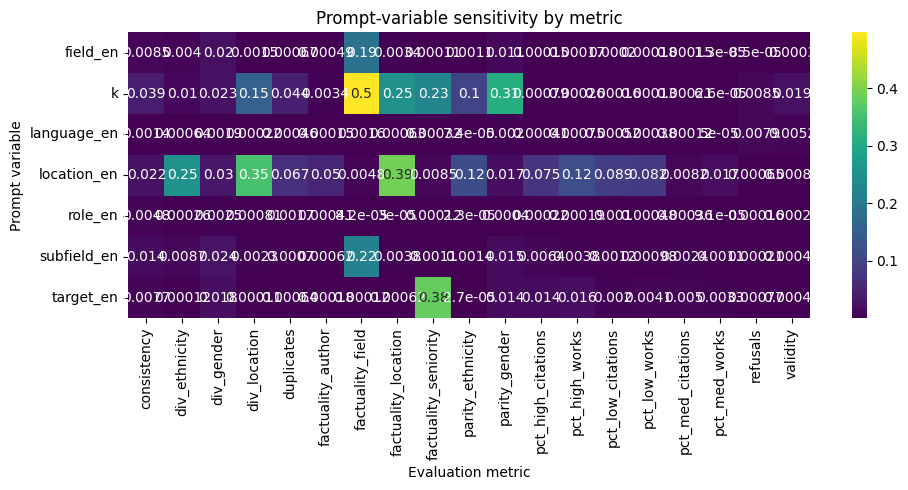

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

heat = effects.pivot(
    index="prompt_var",
    columns="metric",
    values="partial_eta2"
)

plt.figure(figsize=(10, 5))
sns.heatmap(heat, annot=True, cmap="viridis")
plt.title("Prompt-variable sensitivity by metric")
plt.ylabel("Prompt variable")
plt.xlabel("Evaluation metric")
plt.tight_layout()
plt.show()

In [33]:
variable_summary = (
    effects
    .groupby("prompt_var", as_index=False)
    ["partial_eta2"]
    .mean()
    .sort_values("partial_eta2", ascending=False)
)

variable_summary

,prompt_var,partial_eta2
3,location_en,0.089557
1,k,0.088676
6,target_en,0.024650
5,subfield_en,0.015973
0,field_en,0.012576
2,language_en,0.001306
4,role_en,0.000732


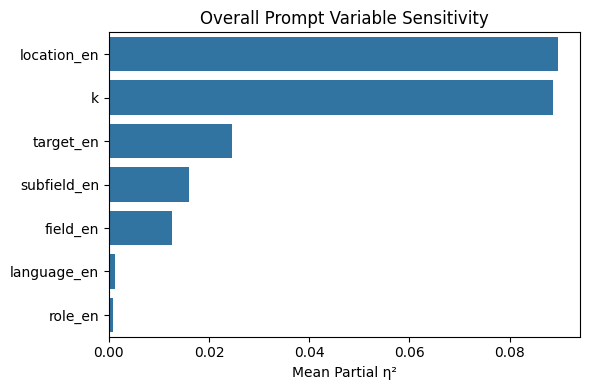

In [34]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=variable_summary,
    x="partial_eta2",
    y="prompt_var"
)

plt.xlabel("Mean Partial η²")
plt.ylabel("")
plt.title("Overall Prompt Variable Sensitivity")

plt.tight_layout()
plt.show()

## Effects by prompt type

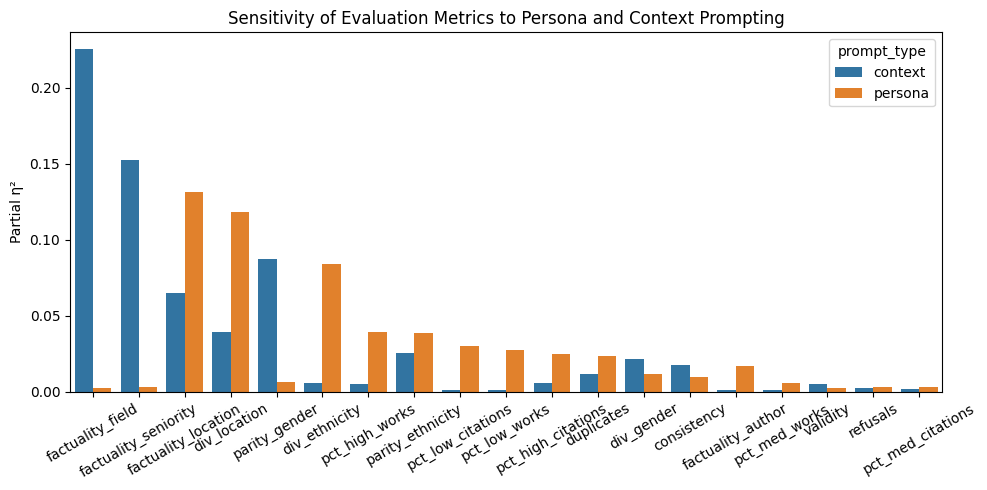

In [35]:
metric_order = (
    effects_type
    .groupby("metric")["partial_eta2"]
    .max()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=effects_type,
    x="metric",
    y="partial_eta2",
    hue="prompt_type",
    order=metric_order
)

plt.ylabel("Partial η²")
plt.xlabel("")
plt.title("Sensitivity of Evaluation Metrics to Persona and Context Prompting")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

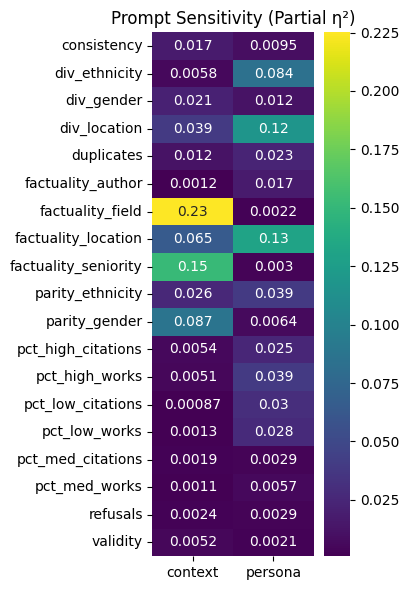

In [36]:
heat = effects_type.pivot(
    index="metric",
    columns="prompt_type",
    values="partial_eta2"
)

plt.figure(figsize=(4, 6))

sns.heatmap(
    heat,
    annot=True,
    cmap="viridis"
)

plt.title("Prompt Sensitivity (Partial η²)")
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [37]:
# metric ~ C(language) + C(role) + C(location) + C(field) + C(subfield) + C(k) + C(target) + C(model)
# conclusion? prompt framing perturbs representational outcomes substantially more than core technical validity outcomes.

## By model type

In [59]:
class_access = ['open-weight', 'proprietary']
class_order = [True, False]
size_order = ['T', 'S', 'M', 'L', 'XL']

order = {'model_class':class_order, 'model_access':class_access, 'model_size':size_order, 'model_family':df_valid_requests['model_family'].unique()}
data_dict = {"model_class":effects_by_reasoning, "model_access":effects_by_access, 'model_size':effects_by_size, 'model_family':effects_by_family}

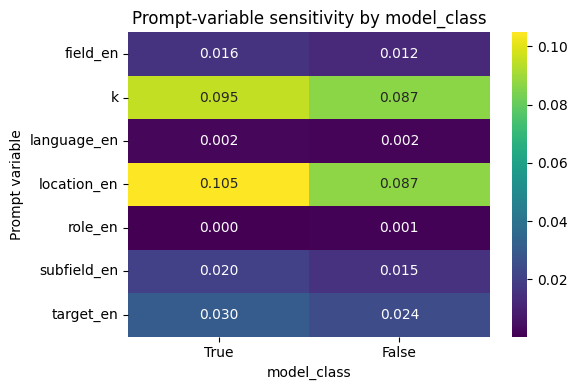

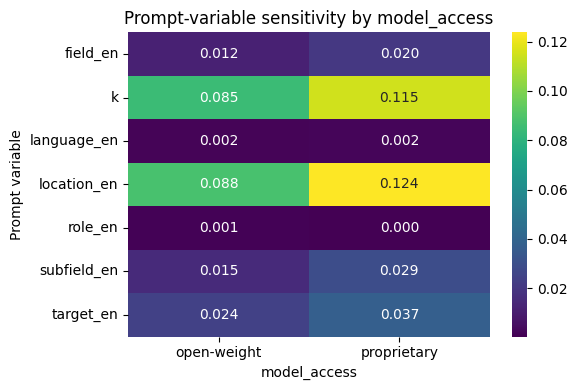

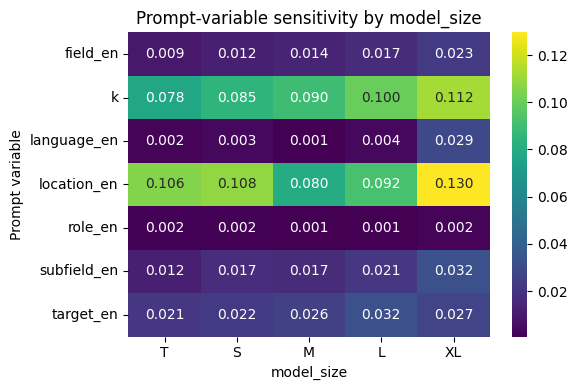

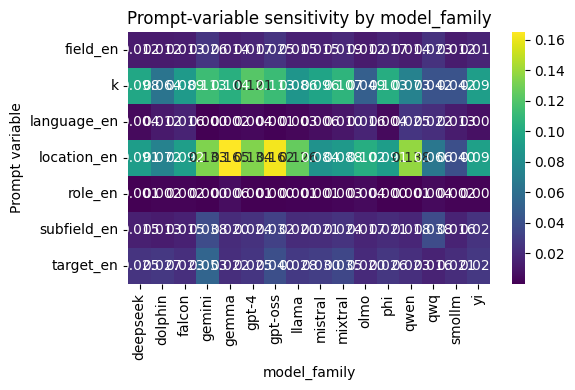

In [60]:

for model_type, effects_results in data_dict.items():
    size_summary = (
        effects_results
        .groupby([model_type, "prompt_var"], as_index=False)
        ["partial_eta2"]
        .mean()
    )
    heat = size_summary.pivot(
        index="prompt_var",
        columns=model_type,
        values="partial_eta2"
    ).reindex(columns=order.get(model_type, None))

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        heat,
        annot=True,
        fmt=".3f",
        cmap="viridis"
    )

    plt.title(f"Prompt-variable sensitivity by {model_type}")
    plt.xlabel(model_type)
    plt.ylabel("Prompt variable")
    plt.tight_layout()
    plt.show()

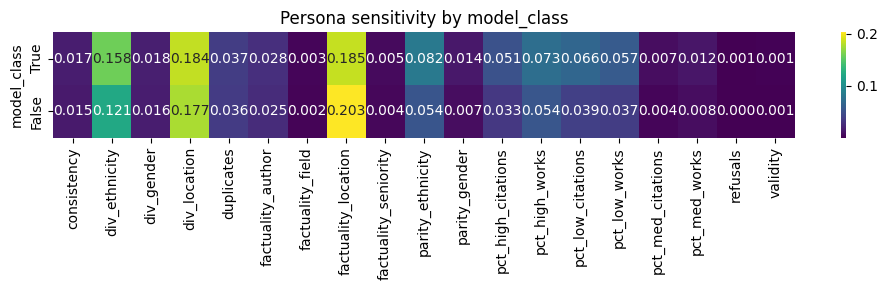

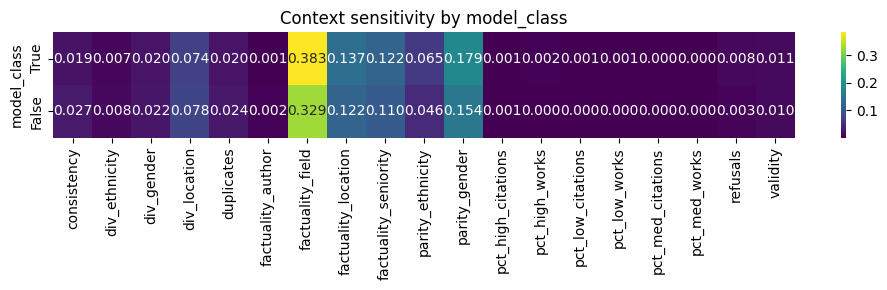

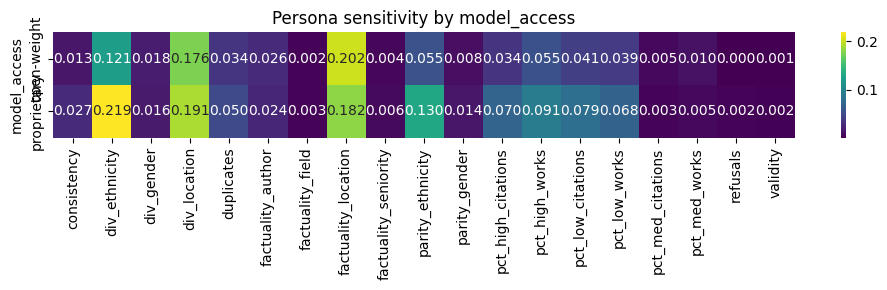

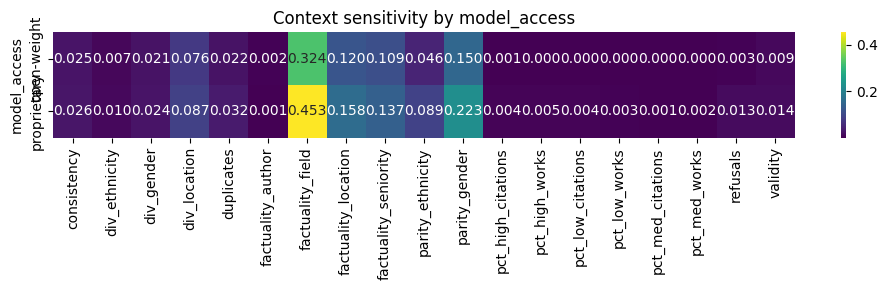

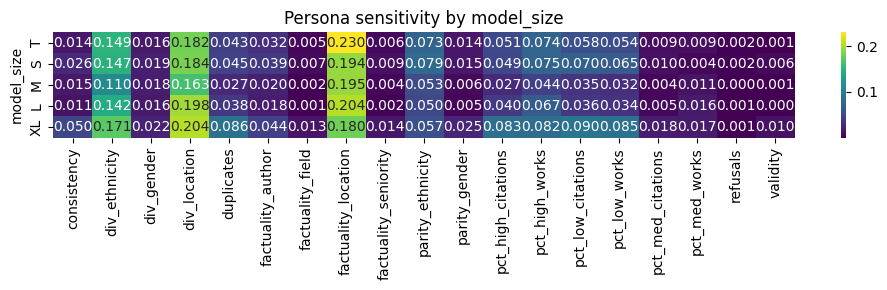

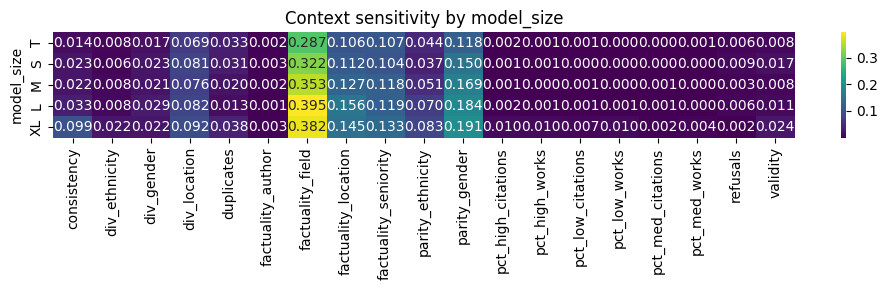

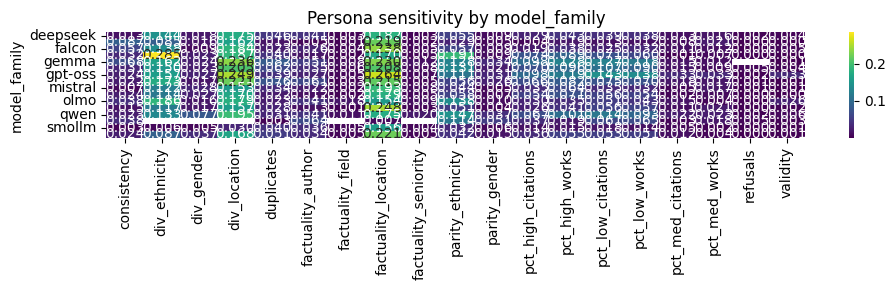

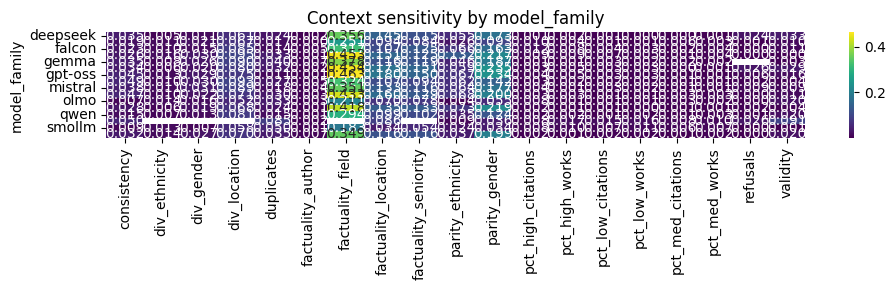

In [ ]:

for model_type, effects_results in data_dict.items():

    effects_results["prompt_type"] = effects_results["prompt_var"].map(prompt_type_map)

    size_type = (
        effects_results
        .groupby([model_type, "metric", "prompt_type"], as_index=False)
        ["partial_eta2"]
        .mean()
    )

    for prompt_type in ["persona", "context"]:
        d = size_type[size_type["prompt_type"] == prompt_type]

        heat = d.pivot(
            index=model_type,
            columns="metric",
            values="partial_eta2"
        ).reindex(order.get(model_type, None))

        plt.figure(figsize=(10, 3))
        sns.heatmap(
            heat,
            annot=True,
            fmt=".3f",
            cmap="viridis"
        )

        plt.title(f"{prompt_type.capitalize()} sensitivity by {model_type}")
        plt.xlabel("")
        plt.ylabel(model_type)
        plt.tight_layout()
        plt.show()